In [1]:
from astrolab import imaging as im
from astrolab import photometry as phot
import numpy as np
import matplotlib.pyplot as plt
from astrolab import spectroscopy as spec
from scipy.optimize import curve_fit
from scipy import ndimage as scp
from astrolab import photometry as phot
from matplotlib import image as mpimg


## The primary connected componenets analysis has been done using Scipys ndimage module

In [2]:
#r_sun= radius of the sun

# plt.rcParams['figure.dpi']=100
r_sun=1516

## Defining all the required functions

1) display_spot:  to display the images
2) b_roth:  Bradley roth thresholding
3) mask_sun: creates a mask
4) this_crop, find_spot:   crop the masked image, give us co ordinates of the spot

In [3]:
#can be used to display a single image. For example:     image_1= display_spot(array)

def display_spot(array, fig=None, ax=None, cmap="Greys_r"):
    if fig is None or ax is None:
        fig, ax = plt.subplots()
    ax.imshow(array, cmap="Greys_r", origin='lower', extent=[-r_sun, +r_sun, -r_sun, +r_sun])


In [127]:
def b_roth(image_main, threshold, Nx=100,  print_log=True):

    image= np.array(image_main).astype(float)  #converting the image to an array

    # left,right,top,bottom, mask = mask_sun(image)
    # image = mask*image

    s=image.shape[1]//Nx  #defining our window size in the format column/integer
    
    t=threshold
     
   
    #performing integral imaging
    int_image=np.cumsum(np.cumsum(image, axis=1), axis=0)  
    rows, cols= int_image.shape[:2]
    x,y= np.meshgrid(np.arange(cols), np.arange(rows))


    #turns x into an orderd set/ ordeers the array as per its order x11,x12,x13,......xMN
    x=x.ravel()                                           
    y=y.ravel()


    x_1=x-s//2          #rows
    x_2=x+s//2        
    y_1=y-s//2          #columns
    y_2=y+s//2


    x_1[x_1 < 0] = 0                     
    y_1[y_1 < 0] = 0                      
    x_2[x_2 >= cols] = cols-1             #creating a mask which prevents any value from exceeding 6000 (max columns you can have)   
    y_2[y_2 >= rows] = rows-1

    count = (x_2-x_1)*(y_2-y_1)

    sum= int_image[y_2,x_2] - int_image[(y_1-1),x_2] - int_image[y_2,(x_1-1)] + int_image[(y_1-1),(x_1-1)]

    result = np.ones(rows*cols, dtype=bool)
    result[image.ravel()*count<= sum*(100-t)/100.0] = False
   
    #displaying the image
    result = np.reshape(result, (rows, cols)).astype(int)
    
    if(print_log):
        plt.imshow(result, cmap='grey', origin='lower')
        plt.title( f'Bradley Roth Image [window size={Nx}]')
    return result
    

In [5]:
#creates a mask and crops the image for us. Also helps us locate the sunpsot using the im.find_spot function from astrolab

def mask_sun(image_array, sun_threshold = 50, print_log=False, crop=True):
    #creating a mask
    mask = ~(image_array<sun_threshold)
    if(print_log):
        plt.hist(image_array.flatten())
        plt.show()

    v=np.mean(mask,axis=0)  #vertical average
    v1=np.argwhere(v>0)

    h=np.mean(mask,axis=1)  #horizontal average
    h1=(np.argwhere(h>0))

    left   =   v1[0][0]
    right  =   v1[-1][0]
    bottom    =   h1[0][0]
    top =   h1[-1][0]

    if(print_log):
        display_mask= im.display(mask*image_array, stretch='linear')
        plt.gca().axhline(h1[0], color='firebrick')
        plt.gca().axvline(v1[0], color='firebrick')
        plt.gca().axhline(h1[-1], color='firebrick')
        plt.gca().axvline(v1[-1], color='firebrick')
        print(left,right,top,bottom)   #crop values 

    if(crop):
        
        image_array = mask*image_array
        return im.crop(image_array, left=left, right=right, top=top, bottom=bottom)
    else:
        return left, right, top, bottom, mask


def display(array):
    im.display(array, stretch='linear')


def find_spot(array, spot_pos, search=100, print_log=False, fig=None, ax=None):
    if(print_log and (fig is None or ax is None)):
        fig,ax= plt.subplots()
    
    inverted_array = np.max(array)-array
    
    this_spot = im.find_star(inverted_array, star_pos=spot_pos, search=search, print_log=False)

    if(print_log):
        
        ax.imshow(array, cmap="Greys_r", origin='lower', extent=[-r_sun, +r_sun, -r_sun, +r_sun])
        ax.scatter(1515,1515)
        # im.display(array, stretch='linear', fig=fig, ax=ax, min_percent=40, max_percent=80)
        ax.scatter(this_spot[0], this_spot[1], facecolor='none', ec='r')
       
    return this_spot

## Load images

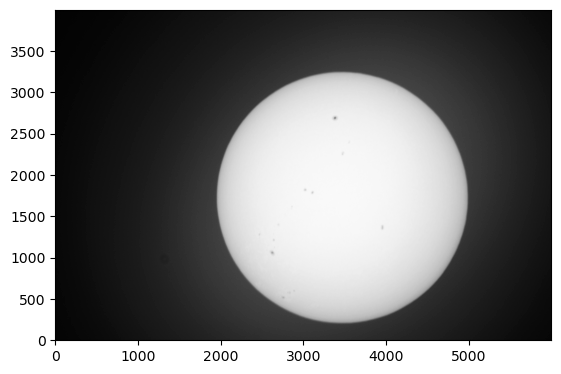

In [357]:
#1)load the images and store under variables  
#2)Add variable to image list
#3)Provide rough ocation of desired spot

# raw_27=im.load_image("/Users/soumit/Downloads/Astronomy/Sun Spots/20240720/1:15s/DSC_1425.JPG")
raw_27=im.load_image("/Users/soumit/Downloads/Astronomy/Sun Spots/20240627/DSC_1036.JPG")
sidc_27=im.load_image("/Users/soumit/Downloads/Astronomy/Sun Spots/27.JPG")

new_27_10= im.load_image('/Users/soumit/Downloads/new27.jpeg')

filter_sidc= scp.gaussian_filter(sidc_27, sigma=0.3, radius= 2)
filter_raw= scp.gaussian_filter(raw_27, sigma=0.5, radius= 2)

im.display(filter_raw, stretch='linear')
image_list = [filter_raw, filter_sidc,new_27_10]
rough_spot = [[-900,-700],[-250,500] ,[220,450]]



In [296]:
# filter= scp.gaussian_filter(raw_27, sigma=0.2, radius=2)
# im.display(filter, stretch='linear')


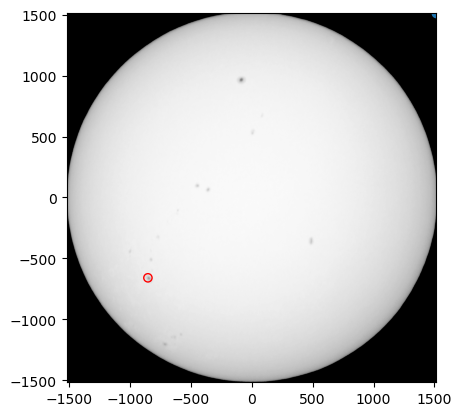

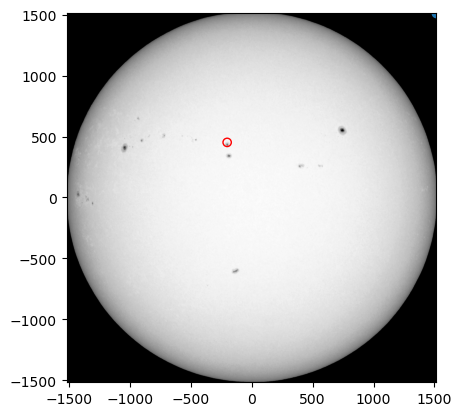

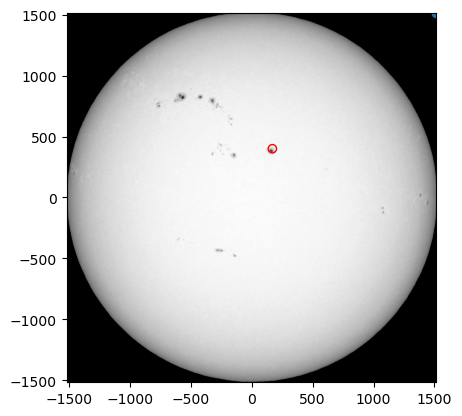

In [297]:
# Use these images to provide more accurate spot positions under 'rough_spot'

def process(image, spot_pos, print_log=False, fig=None, ax=None):   #print_log True to see cropping data and spot co ordinates
    if print_log and (fig is None or ax is None):
        fig, ax = plt.subplots()
    this_crop = mask_sun(image, print_log=False)
    this_spot = find_spot(this_crop, spot_pos=spot_pos, print_log=print_log, fig=fig, ax=ax)

    return this_crop, this_spot

crop_list = []
spot_list = []
for i in range(len(image_list)):
    this_crop, this_spot = process(image_list[i], spot_pos = rough_spot[i], print_log=True)   #print_log= True to see the images
    crop_list.append(this_crop)
    spot_list.append(this_spot)

spot_list = np.array(spot_list)



In [464]:
# br_mask_sidc= b_roth((),9, Nx=50)
# #creating a b roth mask
# filter_sidc= scp.gaussian_filter(br_mask_sidc, sigma=0.5, radius=2)
# plt.title('gauss filter + cropped sidc image')
# im.display(filter_sidc, stretch='linear')
# plt.title('cropped sidc image')


gauss= scp.gaussian_filter(crop_list[1], sigma=0.5, radius=2)

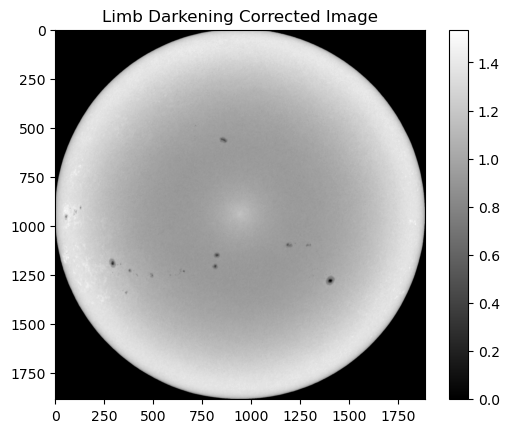

In [465]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


# Load the image using skimage (you could replace this with another loader if needed)
image = gauss.astype(float)  # Ensure image is in float for intensity calculations

# Get the center of the image
h, w = image.shape
center_x, center_y = w // 2, h // 2

# Calculate distances of each pixel from the center
y, x = np.indices((h, w))
radii = np.sqrt((x - center_x)**2 + (y - center_y)**2).astype(int)

# Initialize a list to store median intensities for each radius
max_radius = int(radii.max())
median_intensity = []

# Calculate the median intensity for each radius
for r in range(max_radius + 1):
    mask = (radii == r)
    if np.any(mask):
        median_intensity.append(np.median(image[mask]))
    else:
        median_intensity.append(0)  # Handle case where radius isn't found (usually edges)

# Define a polynomial function of degree 3 for fitting
def polynomial_3rd_degree(r, a, b, c, d):
    return a * r**3 + b * r**2 + c * r + d

# Perform the polynomial fit
r_values = np.arange(max_radius + 1)
params, _ = curve_fit(polynomial_3rd_degree, r_values, median_intensity)

# Create an intensity profile function using the fitted polynomial
intensity_profile = polynomial_3rd_degree(r_values, *params)

# Apply the correction to each pixel
corrected_image = np.zeros_like(image)
for r in range(max_radius + 1):
    mask = (radii == r)
    if intensity_profile[r] != 0:  # Avoid division by zero
        corrected_image[mask] = image[mask] / intensity_profile[r]

# Display the corrected image
plt.imshow(corrected_image, cmap='gray')
plt.title("Limb Darkening Corrected Image")
plt.colorbar()
plt.show()


In [466]:




# center = (crop_list[0].shape[0] // 2, crop_list[0].shape[1] // 2)
# y, x = np.indices(crop_list[0].shape)
# radius = np.sqrt((x - center[1])**2 + (y - center[0])**2)

# # Step 2: Normalize based on the radial profile
# mean_radius = np.mean(crop_list[0], axis=0)  # Approximate radial falloff
# normalized_img = crop_list[0] / (mean_radius[radius.astype(int)] + 1e-5)  # Avoid division by zero

# # Optional: Smooth to prevent artifacts
# normalized_img = scp.gaussian_filter(normalized_img, sigma=0.3, radius=5)

Text(0.5, 0.92, 'Original Image x Corrected Image')

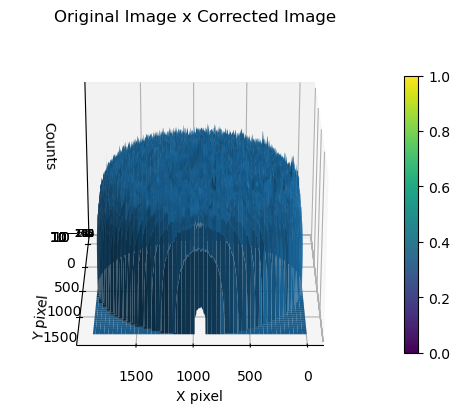

In [468]:
# morph=im.display(normalized_img, stretch='linear')
# morph=np.array(morph)
im.display3D(crop_list[1]*corrected_image)
plt.title('Original Image x Corrected Image')

Text(0.5, 0.92, 'Original Image')

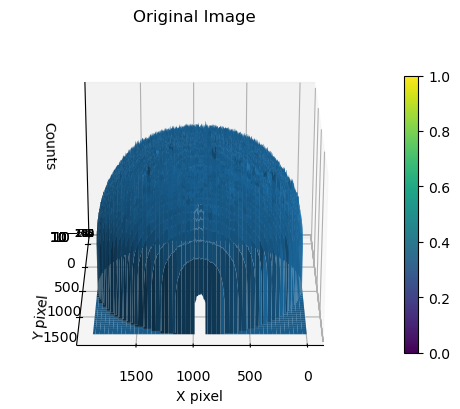

In [471]:
im.display3D(crop_list[1])
plt.title('Original Image')

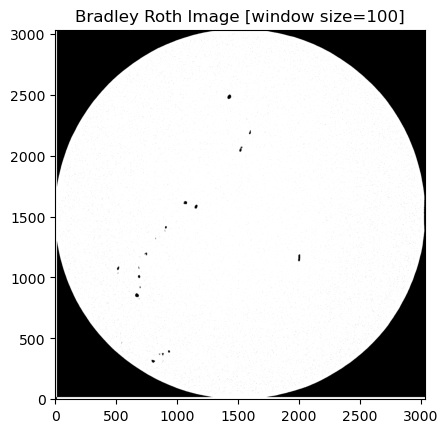

In [475]:
br_mask=b_roth(crop_list[0], 9, Nx=100)

Text(0.5, 1.0, 'Image after morphological process')

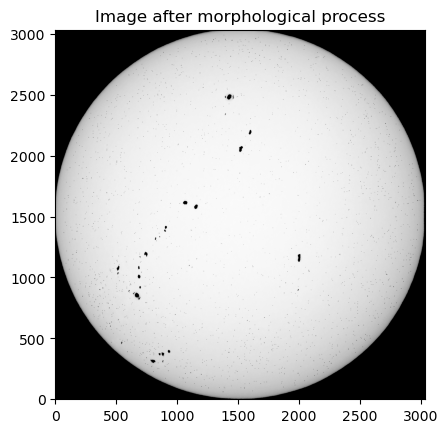

In [439]:
structuring_element = np.ones((3, 3) ) # Adjust as necessary
opened_mask = scp.binary_opening(crop_list[0], structure=structuring_element)
closed_spots = scp.binary_closing(br_mask, structure=structuring_element)

# Multiply closed mask with normalized image to isolate sunspots on uniform background
isolated_sunspots = closed_spots*crop_list[0]*opened_mask

im.display(isolated_sunspots, stretch='linear')
plt.title('Image after morphological process')

Component 1: Area = 1985901 pixels
Component 589: Area = 1085 pixels
Component 852: Area = 1126 pixels
Component 1483: Area = 1008 pixels
Component 1744: Area = 1175 pixels


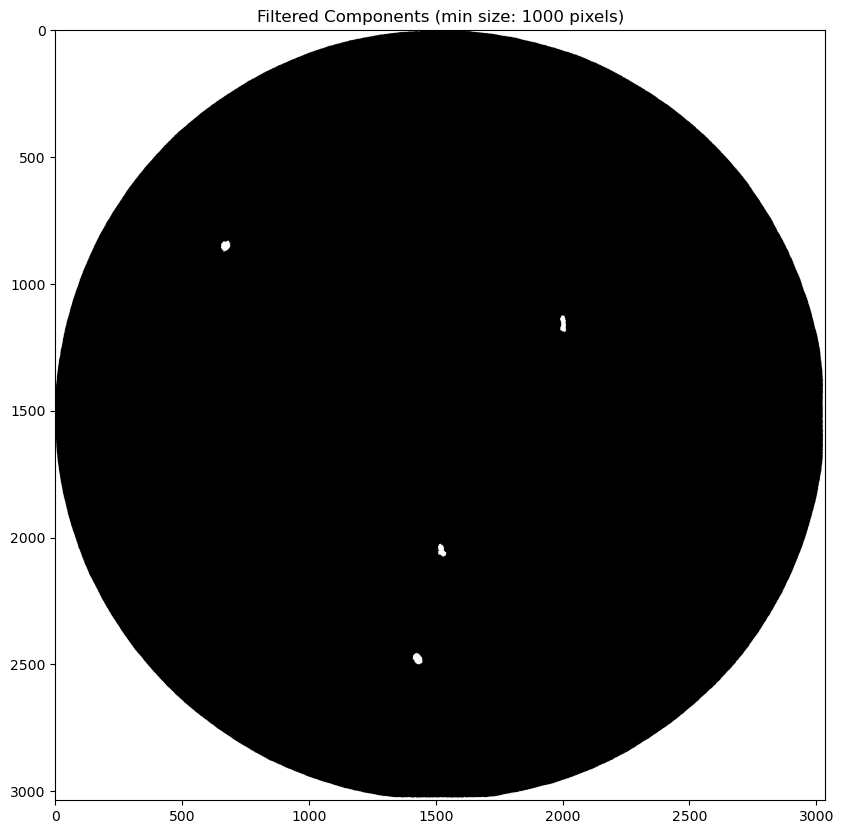

In [440]:

labeled_image, num_components = scp.label(isolated_sunspots== 0)  # Finds connected 0 (sunspots are assigned 0)
min_size= 1000#Threshold

component_sizes = np.bincount(labeled_image.ravel())[1:]  # Skip background (label 0)
    


#Finding the bounding boxes for each labeled component
#A bounding box is a rectangular box that completely encloses an object or a region of interest in an image

bound_box = scp.find_objects(labeled_image)


# Creating a mask of only the large componentsx
large_components = component_sizes >= min_size
filtered_image = np.isin(labeled_image, np.nonzero(large_components)[0] + 1)  # np.isin identifies which components belong to 'large components'


for i, size in enumerate(component_sizes): #checks if each components size is larger than the min threshold (min_size) 
    if size >= min_size:
        print(f"Component {i + 1}: Area = {size} pixels") #display image and component numbers


plt.figure(figsize=(10, 10))
plt.imshow(filtered_image, cmap='Greys_r') 
plt.title(f"Filtered Components (min size: {min_size} pixels)")
plt.show()


#WARNING ! I have not understood how they number the components




Component 77: Bounding box = y axis loc: [248, 252], x axis loc: [851, 854]
Component 77: Height = 4 pixels, Width = 3 pixels


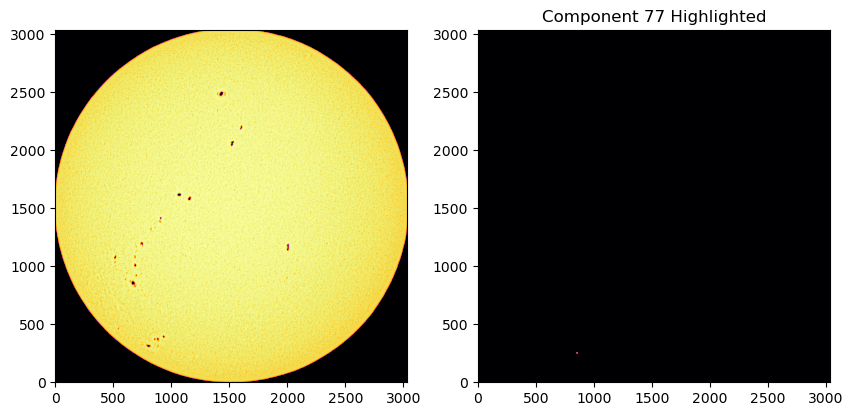

In [441]:
#167388

#2240 2915
target_label= 77
#Replace with your actual component label

if target_label <= num_components: # checking if comp no belongs to component list 

    # A 'target' here is just a component in an array of all the detected components
    
    target_slice = bound_box[target_label - 1]  # Subtract 1 because labels start from 1

    if target_slice:  # If a slice is found
        
        # Get the bounding box coordinates
        y_slice, x_slice = target_slice
        y_start, y_end = y_slice.start, y_slice.stop
        x_start, x_end = x_slice.start, x_slice.stop

        # Print the bounding box coordinates
        print(f"Component {target_label}: Bounding box = y axis loc: [{y_start}, {y_end}], x axis loc: [{x_start}, {x_end}]")
        print(f"Component {target_label}: Height = {y_end - y_start} pixels, Width = {x_end - x_start} pixels")
        
        # Optional: Plot the specific component (highlighted)

        fig,axes =plt.subplots(nrows=1,ncols=2, figsize= (10,10))
        component_image = np.zeros_like(labeled_image)
        component_image[y_slice, x_slice] = labeled_image[y_slice, x_slice] == target_label
        im.display(component_image*crop_list[0],fig=fig, ax=axes[1] ,cmap='inferno')
        im.display(br_mask*crop_list[0],fig=fig, ax=axes[0] , cmap='inferno')
    
        plt.title(f"Component {target_label} Highlighted")
        plt.show()
    else:
        print(f"No component found with label {target_label}")
else:
    print(f"Label {target_label} exceeds the number of components found: {num_components}")



# Print the areas of components larger than the threshold


# Component 40144: Area = 1893 pixels
# 976 pixels

In [442]:
dslr_perpix=457.7

sdo_area= 1187*188
dslr_area= 1952*dslr_perpix
print(sdo_area, dslr_area)

223156 893430.4


In [443]:
dslr_perpix=458.5775436285808
sidc_perpix=738.4411452810181

spot_dslr= 1944 *dslr_perpix**2
spot_sidc=  864*sidc_perpix**2

print('dslr= ',spot_dslr,'sq km','sidc=',spot_sidc,'sq km')

dslr=  408810298.68370223 sq km sidc= 471135160.83796555 sq km


In [444]:
5+4

9

In [445]:
x_new=im.crop(isolated_sunspots, left=500, right=850,bottom=700,top=1000)

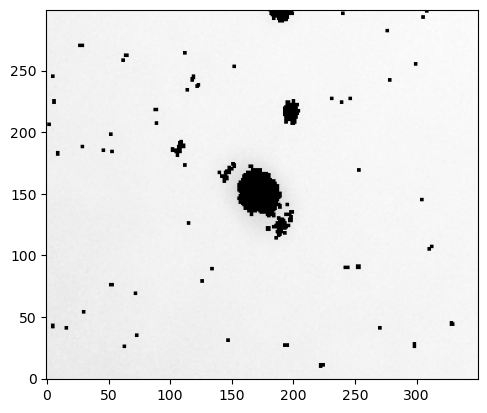

In [446]:
im.display(x_new, stretch='linear')

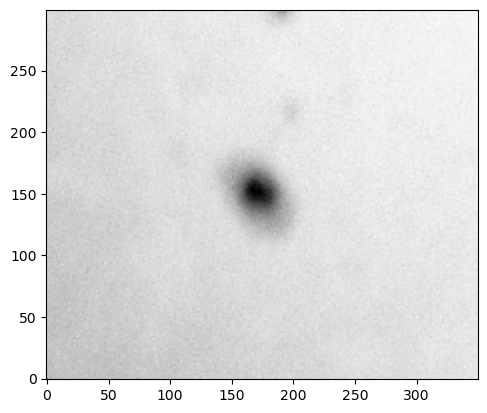

In [447]:
crop_new=im.crop(crop_list[0],  left=500, right=850,bottom=700,top=1000)
im.display(crop_new, stretch='linear')

In [448]:


# Given values
sunspot_area_image = 1126  # example area measured on the image (in pixels)
Rsun = 1511  # radius of the full solar image (in pixels)

# Example coordinates of the sunspot (y, z) in pixels
y = 550  # y-coordinate of the sunspot
z = -300  # z-coordinate of the sunspot

# Calculate the distance r from the image center
r = np.sqrt(y**2 + z**2)

# Calculate the corrected sunspot area
corrected_sunspot_area = sunspot_area_image / np.sqrt(1 - (y/Rsun)**2 - (z/Rsun)**2)

# Print the result
print(f"Corrected Sunspot Area: {corrected_sunspot_area:.2f} pixels")


Corrected Sunspot Area: 1237.37 pixels


In [449]:
import numpy as np

# Sun image properties (adjust values based on your specific image)
angular_radius = 0.27  # Half of 0.53° in degrees
x_center, y_center = 0,0 # Example center coordinates of the Sun in pixels
pixel_radius = 1516 # Example radius of Sun's disk in pixels

# Sunspot coordinates in the image (example values)
x_spot, y_spot = 0,1000

# Step 2: Calculate radial distance in pixels
d_pixels = np.sqrt((x_spot - x_center)**2 + (y_spot - y_center)**2)

# Step 3: Convert to angular distance
angular_distance_per_pixel = angular_radius / pixel_radius
angular_distance = d_pixels * angular_distance_per_pixel

print(f"Angular distance of the sunspot from the center: {angular_distance} degrees")


Angular distance of the sunspot from the center: 0.17810026385224276 degrees


Text(0.5, 1.0, 'Area of spot in MH=136.27±2.54 MH')

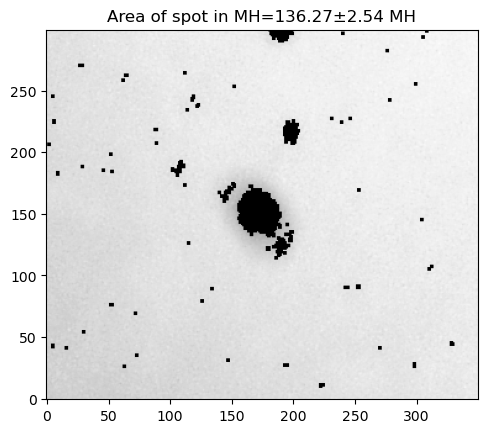

In [457]:
area_mh= spot_dslr/3e6
spot_zoom=im.crop(isolated_sunspots,left=500, right=850,bottom=700,top=1000)
im.display(spot_zoom*crop_new, stretch='linear')
error=(-((area_mh-90)/90)*100)
plt.title(f"Area of spot in MH={area_mh:.2f}±2.54 MH")

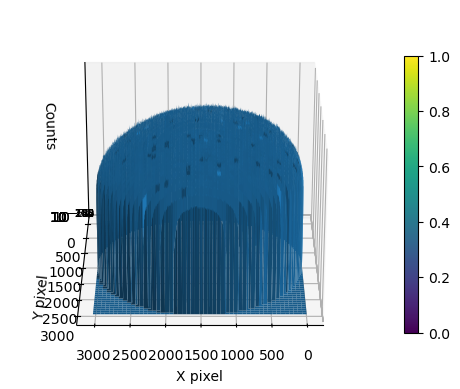

In [407]:
im.display3D(isolated_sunspots)

In [322]:

import numpy as np

# Given values
sunspot_area_image =1276 # example area measured on the image (in pixels)
Rsun = 1511  # radius of the full solar image (in pixels)

# Example coordinates of the sunspot (y, z) in pixels
y = -700 # y-coordinate of the sunspot
z = -900 # z-coordinate of the sunspot

# Calculate the distance r from the image center
r = np.sqrt(y**2 + z**2)

# Calculate the corrected sunspot area
corrected_sunspot_area = sunspot_area_image / np.sqrt(1 - (y/Rsun)**2 - (z/Rsun)**2)

# Print the result
print(f"Corrected Sunspot Area: {corrected_sunspot_area:.2f} pixels")


Corrected Sunspot Area: 1944.52 pixels


Text(0.5, 1.0, 'SIDC Image')

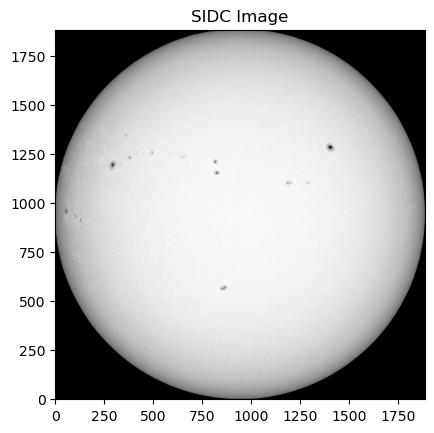

In [473]:
im.display(crop_list[1], stretch='linear')

plt.title('SIDC Image')

Text(0.5, 1.0, 'Original Image x Bradley Roth Mask')

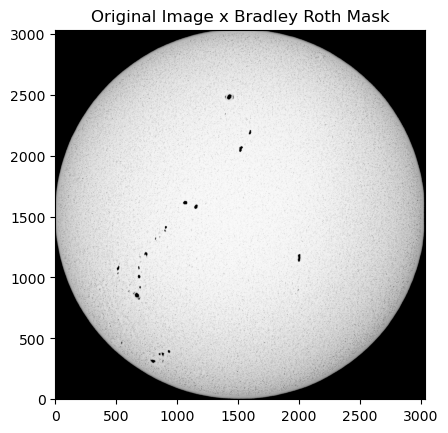

In [349]:
im.display(crop_list[0]*br_mask, stretch='linear')
plt.title('Original Image x Bradley Roth Mask')